In [1]:
from pathlib import Path

from matplotlib import pyplot as plt

import json 
import numpy as np

In [2]:
# ARTIFACT_DIR = Path("../../artifacts/2023-05-S5/experiment-binary-task")
# ARTIFACT_DIR = Path("../../artifacts/2023-05-S5/experiment-binary-task-with-prca-recon")

ARTIFACT_DIR = Path("../../artifacts/2023-05-17-s6/experiment-binary-task-rerun")

In [3]:
def load_stats(dataset, model, layer, basis_name):
    
    
    filepath = ARTIFACT_DIR / dataset / model / layer / basis_name / "stats.json"
    
    
    with open(filepath, "r") as fh:
        stats = json.load(fh)

        aurocs = np.array(stats["arr_auroc"])
        
        original_auroc = stats["original_auroc"]
        
        stats["original_auroc_corrected"] = np.max([original_auroc, 1-original_auroc])
        
        stats["arr_auroc_corrected"] = np.where(aurocs < 0.5, 1-aurocs, aurocs)
        
        
        
    return stats
    
        
load_stats("cifar100-35vs98", "cifar100-resnet18-p1", "layer1", "pca--centered")

{'arr_auroc': [0.5,
  0.5560999512672424,
  0.47680002450942993,
  0.49449998140335083,
  0.47429996728897095,
  0.2685000002384186,
  0.2441999912261963,
  0.22630000114440918,
  0.22499999403953552,
  0.21239998936653137,
  0.20910000801086426,
  0.21649999916553497,
  0.20490001142024994,
  0.20910000801086426,
  0.20749999582767487,
  0.20230001211166382,
  0.21330000460147858,
  0.20489999651908875,
  0.20440000295639038,
  0.21115002036094666],
 'arr_ks': [0,
  1,
  2,
  3,
  4,
  8,
  12,
  16,
  20,
  24,
  28,
  32,
  36,
  40,
  44,
  48,
  52,
  56,
  60,
  64],
 'dims': 64,
 'original_auroc': 0.2111000269651413,
 'original_auroc_corrected': 0.7888999730348587,
 'arr_auroc_corrected': array([0.5       , 0.55609995, 0.52319998, 0.50550002, 0.52570003,
        0.7315    , 0.75580001, 0.7737    , 0.77500001, 0.78760001,
        0.79089999, 0.7835    , 0.79509999, 0.79089999, 0.7925    ,
        0.79769999, 0.7867    , 0.7951    , 0.7956    , 0.78884998])}

In [4]:
class_pairs = """
cifar100-35vs98
cifar100-46vs98
cifar100-55vs72
cifar100-11vs35
cifar100-11vs46
cifar100-24vs72
cifar100-33vs35
cifar100-27vs84
cifar100-65vs67
cifar100-49vs81
""".strip().split("\n")

class_pairs

['cifar100-35vs98',
 'cifar100-46vs98',
 'cifar100-55vs72',
 'cifar100-11vs35',
 'cifar100-11vs46',
 'cifar100-24vs72',
 'cifar100-33vs35',
 'cifar100-27vs84',
 'cifar100-65vs67',
 'cifar100-49vs81']

In [5]:
difficult_pairs, random_pairs = class_pairs[:5], class_pairs[5:]

In [6]:
difficult_pairs

['cifar100-35vs98',
 'cifar100-46vs98',
 'cifar100-55vs72',
 'cifar100-11vs35',
 'cifar100-11vs46']

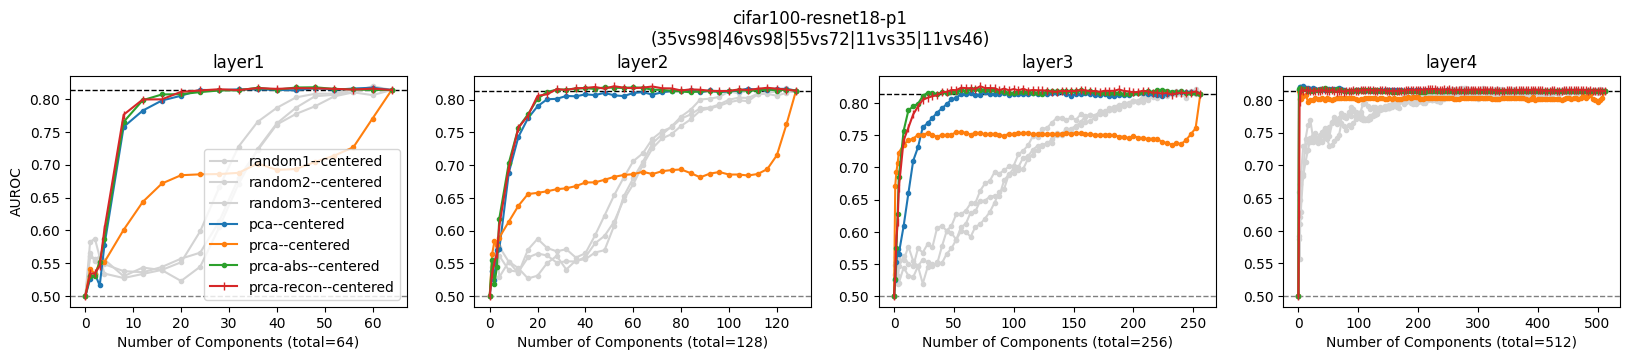

In [7]:
def color(name):
    if "random" in name:
        return 'lightgray'
    else:
        return None
    
def marker(name):
    if "recon" in name:
        return "|"
    else:
        return "."
    
def viz(
    class_pairs,
    model="cifar100-resnet18-p1",
    layers=["layer1", "layer2", "layer3", "layer4"],
    basis_mode="centered"
):
    
    ncols = len(layers)
    
    plt.figure(figsize=(ncols*5, 3))

    plt.suptitle("\n".join(
        [
            model, 
            "(%s)" % "|".join(map(lambda s: s.replace("cifar100-", ""), class_pairs))
        ]),
        y=1.1
    )
    basis_names = list(
        map(
            lambda s: f"{s}--{basis_mode}",
            [
                "random1", "random2", "random3",
                "pca", "prca",
                "prca-abs", "prca-recon"
            ]
        )
    )
    
    for lix, layer in enumerate(layers):
                
        arr_ks = load_stats(class_pairs[0], model, layer, basis_names[0])["arr_ks"]
                
        original_auroc_corrected = []
    
        stat_layer_aurocs = np.zeros((len(class_pairs), len(basis_names), len(arr_ks)))
        
        for pix, pair in enumerate(class_pairs):

            ref_stats = load_stats(pair, model, layer, basis_names[0])
            original_auroc_corrected.append(ref_stats["original_auroc_corrected"])
            for bix, basis_name in enumerate(basis_names):

                stats = load_stats(pair, model, layer, basis_name)

                for k in ["arr_ks", "original_auroc_corrected"]:
                    np.testing.assert_allclose(ref_stats[k], stats[k], err_msg=f"key={k}")
                    
                    
                stat_layer_aurocs[pix, bix, :] = stats["arr_auroc_corrected"]
        
        
        plt.subplot(1, ncols, lix+1)
        plt.title(layer)
        plt.xlabel(f"Number of Components (total={arr_ks[-1]})")
     
        plt.axhline(0.5, alpha=0.5, color="k", ls="--", lw=1)
    
        plt.axhline(np.mean(original_auroc_corrected), ls="--", lw=1, color="k")
        for bix, basis_name in enumerate(basis_names):
            plt.plot(
                arr_ks,
                np.mean(stat_layer_aurocs[:, bix, :], axis=0),
                label=basis_name,
                color=color(basis_name),
                marker=marker(basis_name)
            )
            
            
        if lix == 0:
            plt.ylabel("AUROC")
            plt.legend()

viz(difficult_pairs)

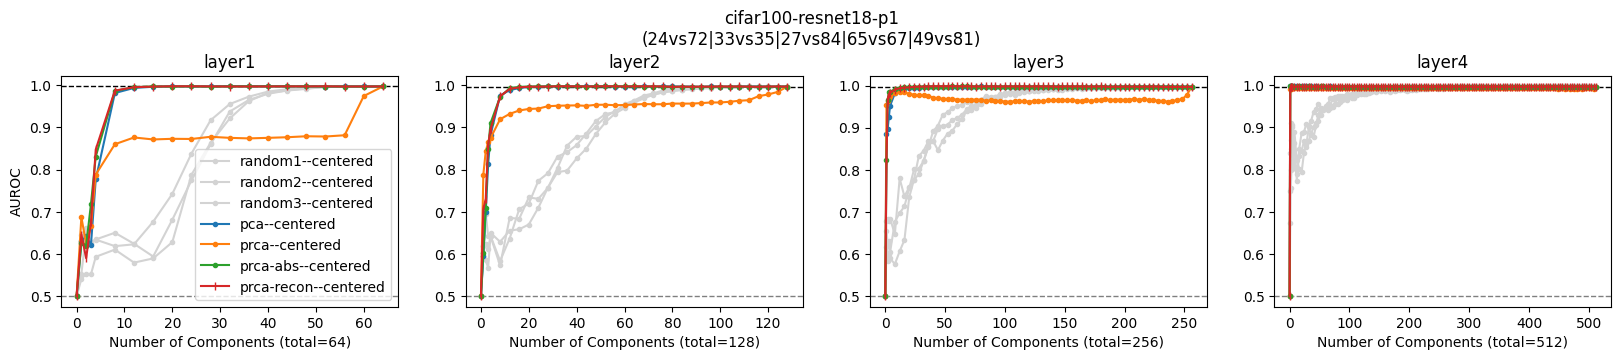

In [8]:
viz(random_pairs)

In [9]:
# viz(difficult_pairs, basis_mode="uncentered")

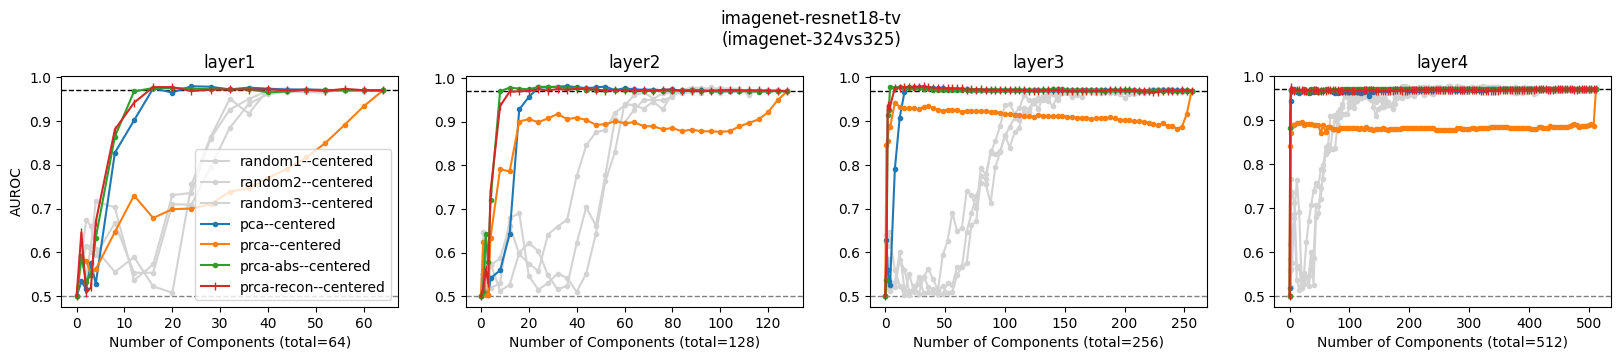

In [10]:
viz(
    ["imagenet-324vs325"],
    model="imagenet-resnet18-tv",
)

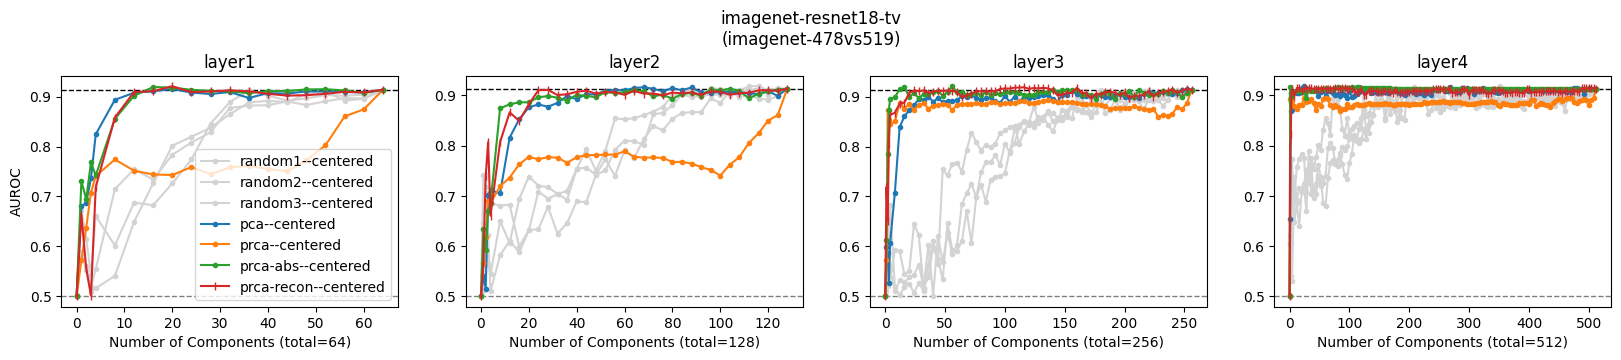

In [11]:
viz(
    ["imagenet-478vs519"],
    model="imagenet-resnet18-tv",
)

In [12]:
# viz(
#     ["imagenet-325vs324"],
#     model="imagenet-resnet18-tv",
# )

In [13]:
# viz(
#     ["imagenet-324vs325"],
#     model="imagenet-resnet18-tv",
#     basis_mode="uncentered"
# )

In [14]:
# viz(
#     ["imagenet-478vs519"],
#     model="imagenet-resnet18-tv",
#     basis_mode="uncentered"
# )

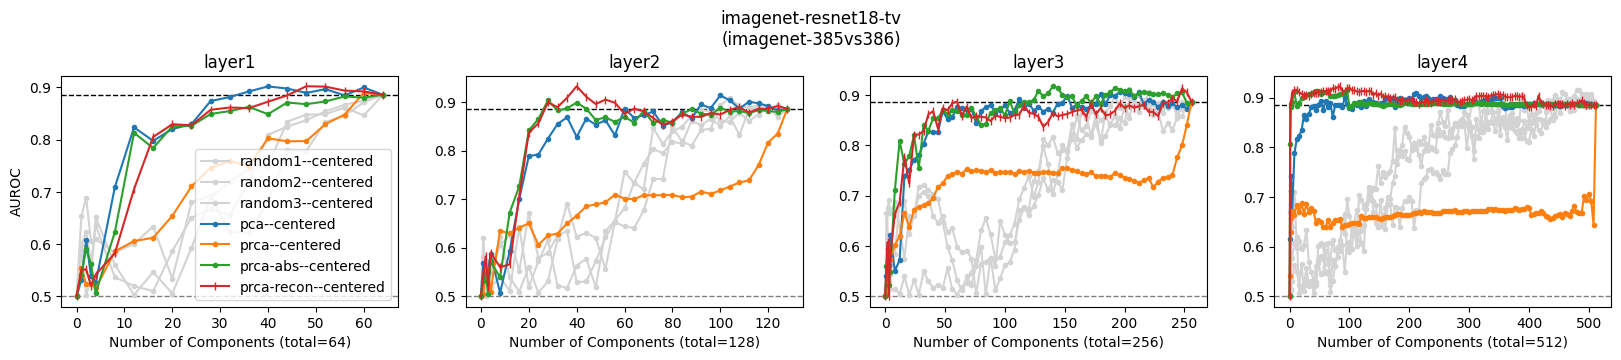

In [15]:
viz(
    ["imagenet-385vs386"],
    model="imagenet-resnet18-tv",
)

In [16]:
# viz(
#     ["imagenet-385vs386"],
#     model="imagenet-resnet18-tv",
#     basis_mode="uncentered"
# )

In [17]:
print("END!")

END!
